Loaded existing lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.39/lattice.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f28bd5bd5c0>
N = 48668
Box L = 50.0
min position = [-24.98597527 -24.98597527 -24.98597527]
max position = [23.89962769 23.89962769 23.89962769]
outside box count = 0
center of mass = [-0.54317338 -0.54317338 -0.54317338]
mean distance from COM = 23.99664302986517
max distance from COM = 42.33617475310795


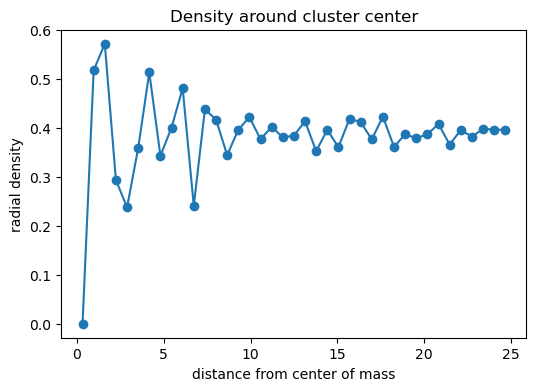

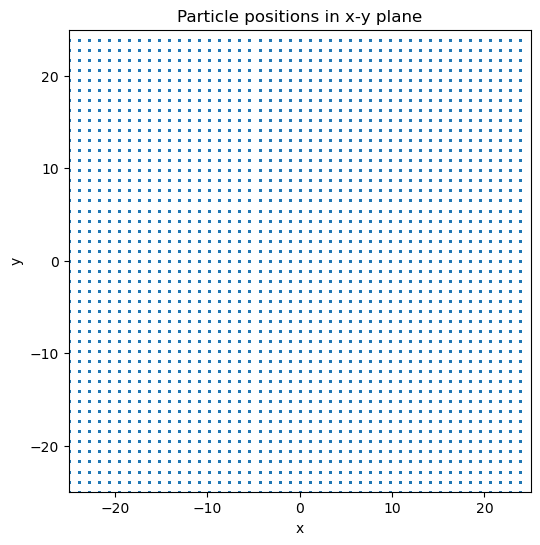

In [23]:
#Grabbing helper scripts
import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


import importlib
importlib.reload(cl)
importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)




##################################################
BoxLength = 50
rho = .39

frame = cl.make_lattice_frame(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="fcc",
)

sim = sh.make_simulation(
    frame,
    kT = .4,
    seed=np.random.randint(0, 100),
)

sim = sh.thermalize_and_randomize(sim, nsteps=0, log = False)


# ============================================================
# Diagnose whether FCC "center clumping" is real or visualization
# ============================================================



import numpy as np
import matplotlib.pyplot as plt
import hoomd

# Get current snapshot
snap = sim.state.get_snapshot()
pos = snap.particles.position.copy()
box = sim.state.box
L = box.Lx

print("N =", snap.particles.N)
print("Box L =", L)
print("min position =", pos.min(axis=0))
print("max position =", pos.max(axis=0))
print("outside box count =", np.sum(np.any((pos < -L/2) | (pos >= L/2), axis=1)))

# Center of mass
com = pos.mean(axis=0)
r_from_com = np.linalg.norm(pos - com, axis=1)

print("center of mass =", com)
print("mean distance from COM =", r_from_com.mean())
print("max distance from COM =", r_from_com.max())

# Radial density around center of mass
bins = np.linspace(0, L/2, 40)
counts, edges = np.histogram(r_from_com, bins=bins)
shell_volumes = 4/3 * np.pi * (edges[1:]**3 - edges[:-1]**3)
rho_r = counts / shell_volumes

plt.figure(figsize=(6,4))
plt.plot(0.5*(edges[1:] + edges[:-1]), rho_r, marker="o")
plt.xlabel("distance from center of mass")
plt.ylabel("radial density")
plt.title("Density around cluster center")
plt.show()

# XY plot
vh.plot_xy_particles(sim)


kT = 0.4
Loaded existing lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.39/lattice.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f28bd49c7d0>


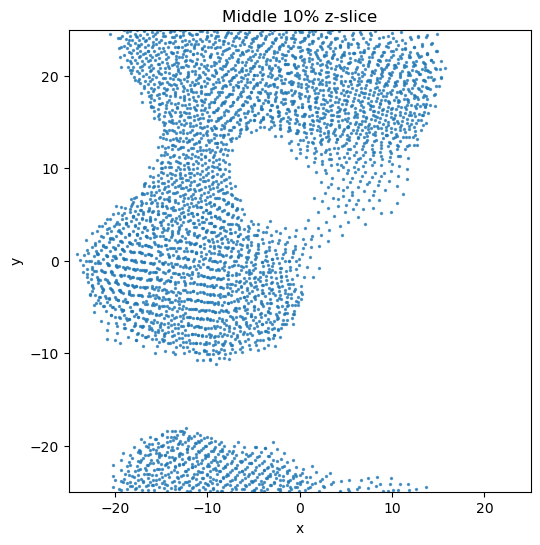

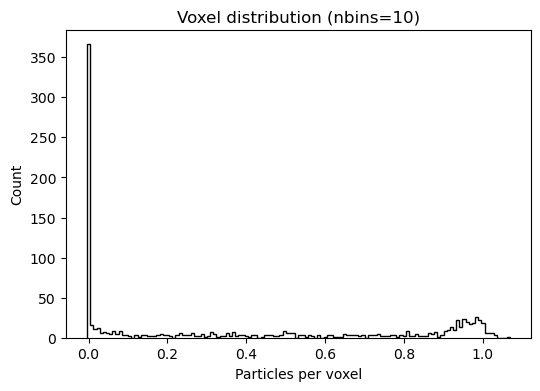

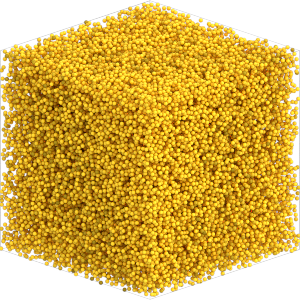


kT = 1.5
Loaded existing lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.39/lattice.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f28bcc7b690>


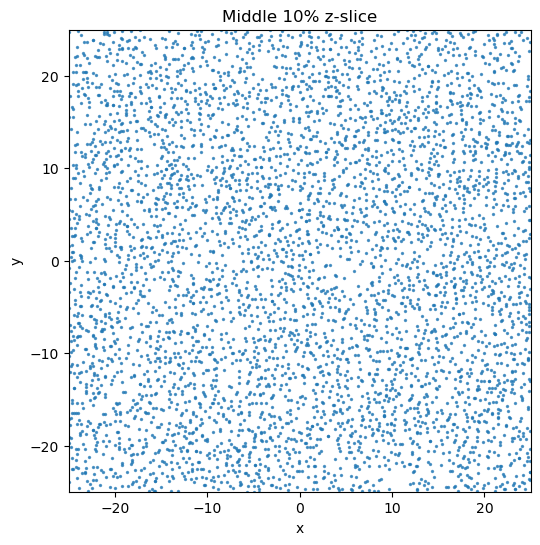

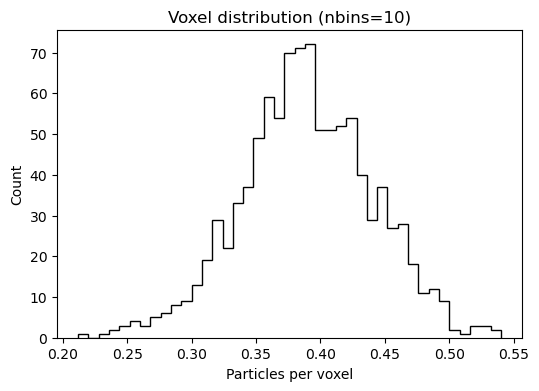

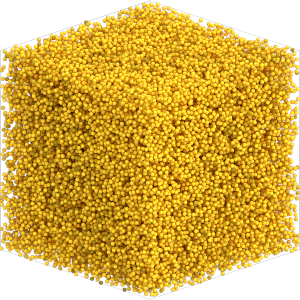


kT = 3.0
Loaded existing lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.39/lattice.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f28bcc7bf50>


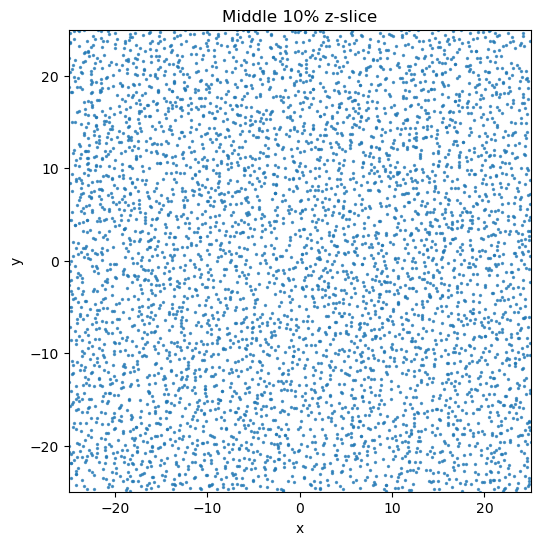

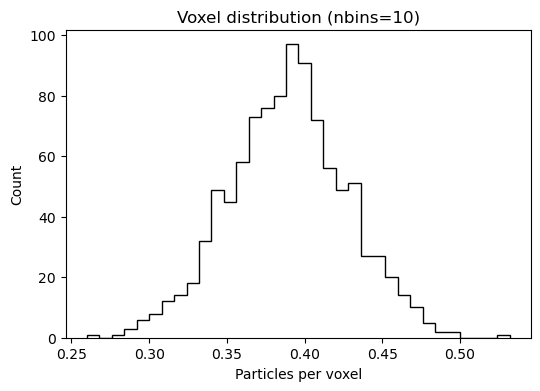

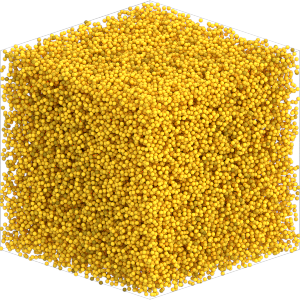

In [21]:
# ============================================================
# Compare low kT vs high kT behavior
# ============================================================

BoxLength = 50.0
rho = 0.39

for kT_test in [0.4, 1.5, 3.0]:
    print("\n" + "="*80)
    print("kT =", kT_test)
    print("="*80)

    frame = cl.make_lattice_frame(BoxLength, rho, lattice_type="fcc")
    sim_test = sh.make_simulation(frame, kT=kT_test)
    
    sim_test.state.thermalize_particle_momenta(
        filter=hoomd.filter.All(),
        kT=kT_test,
    )

    sim_test.run(50_000)

    vh.plot_xy_slice(sim_test, fraction=0.10, point_size=2, alpha=0.7)
    vh.plot_voxel_histogram(sim_test, nbins=10)
    display(vh.render(sim.state.get_snapshot()))